# Exploratory data analysis

## Importing needed packages and loading the DataFrame into pandas

In [80]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mutual_info_score, root_mean_squared_error
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb


ModuleNotFoundError: No module named 'xgboost'

In [3]:
pwd = os.getcwd()
df_original = pd.read_csv(pwd + "/data/StudentPerformanceFactors.csv")

## Sneek peak on what we've got in the table

In [4]:
df_original.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


We observe different columns types with categorical, numerical and binary values. <p>
Binary values seem to be in yes/no format. We will change these to 1/0.

At a first glance all features (columns) seem to be somewhat related to an exam score.

## Checking the data types of the different features

In [5]:
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [6]:
df_original.describe().T

,count,mean,std,min,25%,50%,75%,max
Hours_Studied,6607.0,19.975329,5.990594,1.0,16.0,20.0,24.0,44.0
Attendance,6607.0,79.977448,11.547475,60.0,70.0,80.0,90.0,100.0
Sleep_Hours,6607.0,7.029060,1.468120,4.0,6.0,7.0,8.0,10.0
Previous_Scores,6607.0,75.070531,14.399784,50.0,63.0,75.0,88.0,100.0
Tutoring_Sessions,6607.0,1.493719,1.230570,0.0,1.0,1.0,2.0,8.0
Physical_Activity,6607.0,2.967610,1.031231,0.0,2.0,3.0,4.0,6.0
Exam_Score,6607.0,67.235659,3.890456,55.0,65.0,67.0,69.0,101.0


Comparing the table preview (.head()) with the different stats, we observe:
- Features are correctly formatted
- We got some binary categorical features that are yes/no, we will convert these to 1's and 0's
- Max exam score is 101, which is impossible. We will review this.
- We have numerical features with different ranges. We will scale these.

## Transforming binary categorical values into 1 or 0

In [7]:
df_original.nunique()

Hours_Studied                 41
Attendance                    41
Parental_Involvement           3
Access_to_Resources            3
Extracurricular_Activities     2
Sleep_Hours                    7
Previous_Scores               51
Motivation_Level               3
Internet_Access                2
Tutoring_Sessions              9
Family_Income                  3
Teacher_Quality                3
School_Type                    2
Peer_Influence                 3
Physical_Activity              7
Learning_Disabilities          2
Parental_Education_Level       3
Distance_from_Home             3
Gender                         2
Exam_Score                    45
dtype: int64

We can confirm that we have some yes/no binary categorical features. We will convert these to 1's and 0's.

In [8]:
binary_categorical = ["Extracurricular_Activities","Internet_Access","Learning_Disabilities","School_Type","Gender"]

for col in binary_categorical:
    print(df_original[col].unique())

['No' 'Yes']
['Yes' 'No']
['No' 'Yes']
['Public' 'Private']
['Male' 'Female']


In [9]:
df_original["Extracurricular_Activities"] = (df_original["Extracurricular_Activities"] == "Yes").astype(int)
df_original["Internet_Access"] = (df_original["Internet_Access"] == "Yes").astype(int)
df_original["Learning_Disabilities"] = (df_original["Learning_Disabilities"] == "Yes").astype(int)

df_original["School_Public"] = (df_original["School_Type"] == "Public").astype(int)
df_original["Gender_Male"] = (df_original["Gender"] == "Male").astype(int)

del df_original["School_Type"], df_original["Gender"]

## Reviewing null values

In [10]:
df_original.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Exam_Score                     0
School_Public                  0
Gender_Male                    0
dtype: int64

In [11]:
df_original.shape, df_original.dropna().shape

((6607, 20), (6378, 20))

As the amount or rows with null values are not very significant I will drop them from the dataset

In [12]:
df = df_original.dropna().reset_index(drop=True)


In [13]:
numerical_columns = df.dtypes[df.dtypes == "int64"].index.to_list()
categorical_columns = df.dtypes[df.dtypes == "object"].index.to_list()

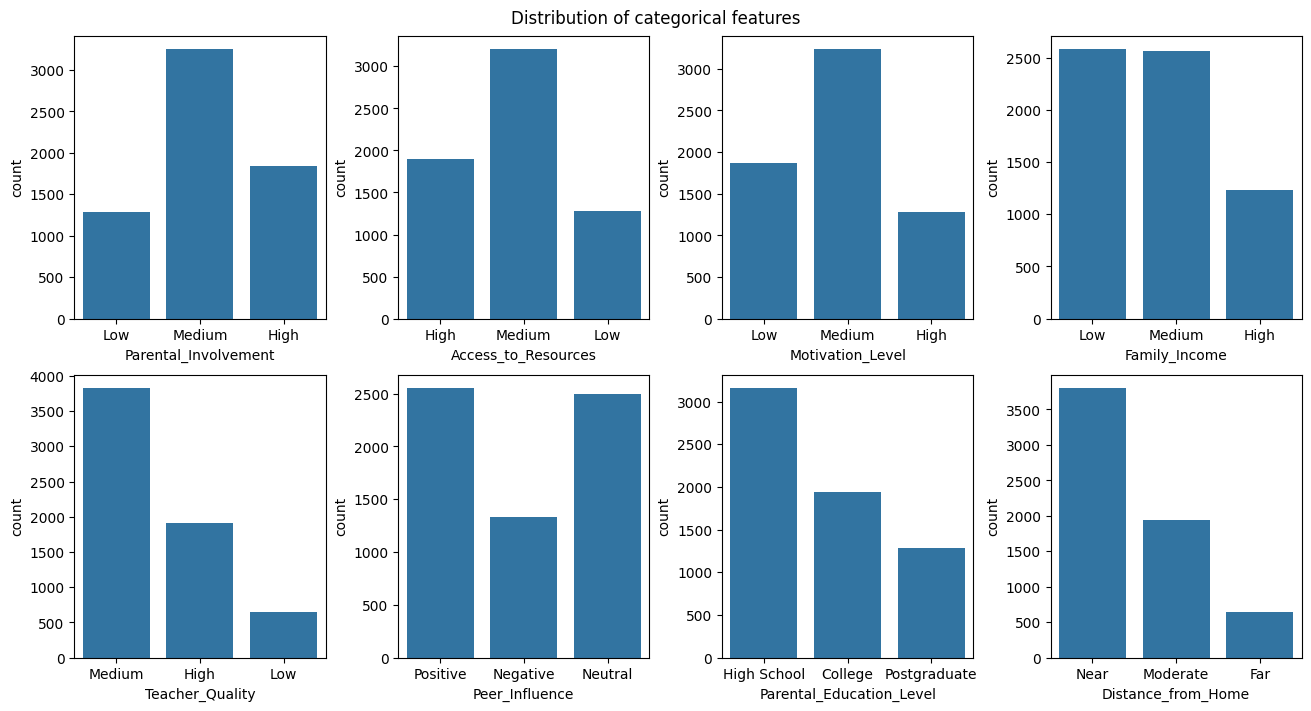

In [14]:
fig, ax = plt.subplots(2,4,constrained_layout=True, figsize=(13,7))
ax = ax.flatten()
for idx, col in enumerate(categorical_columns):
    sns.countplot(data=df, x=col, ax=ax[idx])

plt.suptitle("Distribution of categorical features")
plt.show()

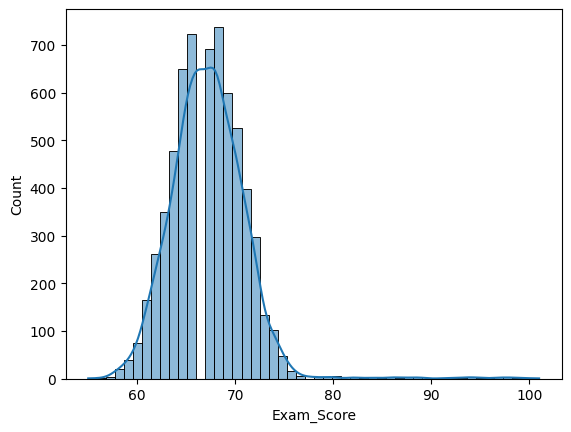

In [15]:
sns.histplot(data=df, x="Exam_Score", kde=True, bins=50)
plt.show()

In [16]:
df.sort_values(by="Exam_Score", ascending=False).head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Exam_Score,School_Public,Gender_Male
1466,27,98,Low,Medium,1,6,93,Low,0,5,High,High,Positive,3,0,High School,Moderate,101,1,0
93,18,89,High,Medium,1,4,73,Medium,1,3,High,Medium,Positive,2,0,College,Near,100,0,0
3455,14,90,High,High,1,8,86,Medium,1,4,Medium,Medium,Negative,2,0,High School,Near,99,0,0
2341,23,83,High,High,1,4,89,Low,1,1,Medium,Medium,Negative,3,0,High School,Far,99,1,1
6131,28,96,High,Low,1,4,98,High,1,1,High,High,Positive,3,0,High School,Near,98,1,1


It's just one student with score over 100 and he seems to have good habits. It seems that someone types 101 instead of 100.

We will cap the scores to 100

In [17]:
df.loc[df.Exam_Score > 100,"Exam_Score"] = 100

## Next we review the correlation between the different numerical features and the exam scores, we also compare the "mutual information" of the different features.


In [18]:
df[numerical_columns].corr()["Exam_Score"].sort_values(ascending=False)

Exam_Score                    1.000000
Attendance                    0.580394
Hours_Studied                 0.445209
Previous_Scores               0.174292
Tutoring_Sessions             0.156769
Extracurricular_Activities    0.063051
Internet_Access               0.051281
Physical_Activity             0.025155
Gender_Male                  -0.004887
School_Public                -0.010898
Sleep_Hours                  -0.017149
Learning_Disabilities        -0.083926
Name: Exam_Score, dtype: float64

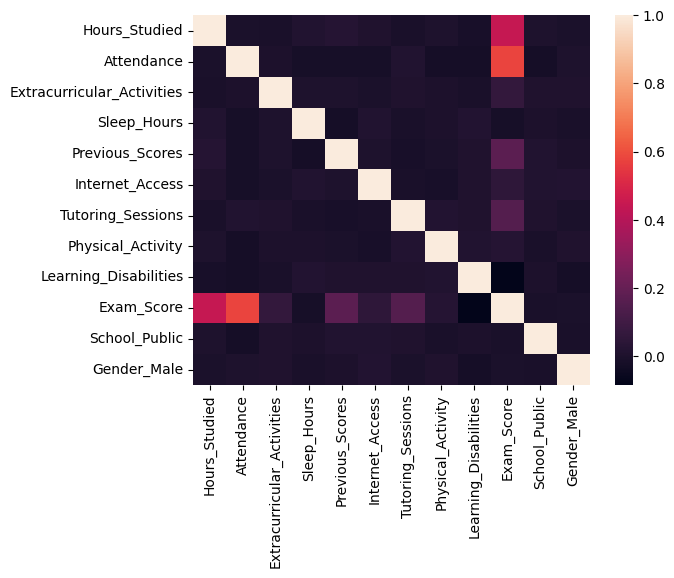

In [19]:
sns.heatmap(df[numerical_columns].corr())
plt.show()

Saving the ranking of features with the least correlation with "Exam Score".

Later we will use these to test removing features

In [20]:
most_correlation_columns = df[numerical_columns].corr()["Exam_Score"].sort_values()[-4:].index.to_list()

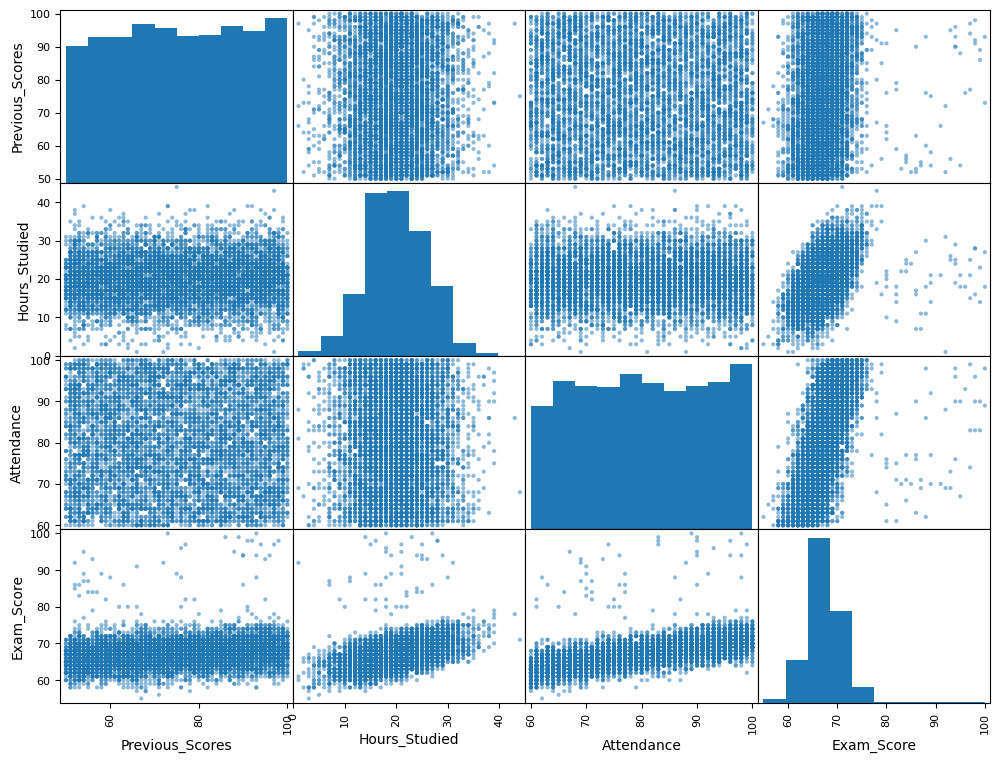

In [21]:
pd.plotting.scatter_matrix(df[most_correlation_columns], figsize=(12,9))
plt.show()

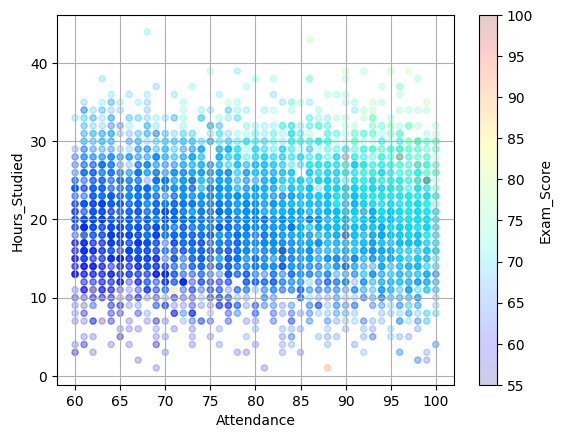

In [22]:
df.plot(kind="scatter", x="Attendance",y="Hours_Studied", grid=True, alpha=0.2, c="Exam_Score", cmap="jet", colorbar=True)
plt.show()

We observe that the attendance does not affec the studing habits. People with low attendance study as much as people with high attendace.

Judging by the chart, students who study more and attend more have better scores

In [23]:
y = df["Exam_Score"]

def mi_score(col):
    return mutual_info_score(col, y)

df.apply(mi_score).sort_values(ascending=False)[1:]

Attendance                    0.378576
Hours_Studied                 0.227219
Previous_Scores               0.120324
Tutoring_Sessions             0.034771
Access_to_Resources           0.027765
Parental_Involvement          0.022979
Physical_Activity             0.017784
Sleep_Hours                   0.017053
Parental_Education_Level      0.015201
Peer_Influence                0.013447
Family_Income                 0.012128
Distance_from_Home            0.011787
Motivation_Level              0.011314
Teacher_Quality               0.009553
Learning_Disabilities         0.009357
Extracurricular_Activities    0.006338
Internet_Access               0.004901
Gender_Male                   0.004822
School_Public                 0.003758
dtype: float64

In [24]:
mi_col_rank_desc = df.apply(mi_score).sort_values(ascending=False)[1:].index

# Preparing the data for ML models

In [25]:
y = df["Exam_Score"]
df = df.drop(columns=["Exam_Score"])


In [26]:
df_full_train, df_test, y_full_train, y_test = train_test_split(df, y, test_size=.20, random_state=10)
df_train, df_val, y_train, y_val = train_test_split(df_full_train, y_full_train, test_size=.25, random_state=10)

In [27]:
df_full_train = df_full_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_train = df_train.reset_index(drop=True)

y_full_train = y_full_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)


In [28]:
df_full_train.shape, y_full_train.shape, df_test.shape, y_test.shape, df_train.shape, y_train.shape, df_val.shape, y_val.shape

((5102, 19),
 (5102,),
 (1276, 19),
 (1276,),
 (3826, 19),
 (3826,),
 (1276, 19),
 (1276,))

In [29]:
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
Hours_Studied,3826.0,20.004705,5.985995,1.0,16.0,20.0,24.0,43.0
Attendance,3826.0,80.177470,11.522805,60.0,70.0,80.0,90.0,100.0
Extracurricular_Activities,3826.0,0.594616,0.491030,0.0,0.0,1.0,1.0,1.0
Sleep_Hours,3826.0,7.030580,1.460721,4.0,6.0,7.0,8.0,10.0
Previous_Scores,3826.0,74.863042,14.446966,50.0,63.0,75.0,88.0,100.0
Internet_Access,3826.0,0.923419,0.265961,0.0,1.0,1.0,1.0,1.0
Tutoring_Sessions,3826.0,1.500000,1.244964,0.0,1.0,1.0,2.0,8.0
Physical_Activity,3826.0,2.968636,1.023928,0.0,2.0,3.0,4.0,6.0
Learning_Disabilities,3826.0,0.105071,0.306684,0.0,0.0,0.0,0.0,1.0
School_Public,3826.0,0.693936,0.460917,0.0,0.0,1.0,1.0,1.0


We will select only real numerical features for the scaler (exluding binary features as School_Public, Gender_Male, Extracurricular_Activities, Internet_Access and Learning_Disabilities)

In [30]:
df_train.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,School_Public,Gender_Male
0,12,62,High,High,1,6,63,High,1,0,Low,Medium,Negative,2,0,High School,Near,0,1
1,28,62,Low,High,0,8,85,Medium,1,2,Low,High,Positive,3,0,High School,Moderate,1,0
2,17,62,Medium,Medium,0,7,66,High,1,2,High,Medium,Neutral,4,0,High School,Moderate,1,1
3,16,78,Medium,Medium,1,4,78,Medium,1,5,High,Medium,Positive,3,0,High School,Near,1,0
4,20,97,High,High,1,7,97,Low,1,2,Medium,High,Neutral,4,0,High School,Moderate,0,0


In [31]:
df_train.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'School_Public',
       'Gender_Male'],
      dtype='object')

In [32]:
categorical_columns

['Parental_Involvement',
 'Access_to_Resources',
 'Motivation_Level',
 'Family_Income',
 'Teacher_Quality',
 'Peer_Influence',
 'Parental_Education_Level',
 'Distance_from_Home']

In [33]:
features_to_scale = ['Hours_Studied','Attendance','Sleep_Hours','Previous_Scores','Tutoring_Sessions','Physical_Activity',]


In [34]:
numerical_columns = ['Hours_Studied','Attendance','Extracurricular_Activities','Sleep_Hours','Previous_Scores',
                     'Internet_Access','Tutoring_Sessions','Physical_Activity','Learning_Disabilities','School_Public','Gender_Male']

In [35]:
len(categorical_columns), len(numerical_columns), len(df_train.columns.to_list())

(8, 11, 19)

In [36]:
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [37]:

numerical_pipeline = make_pipeline(StandardScaler())
categorical_pipeline = Pipeline([
    ("onehot", OneHotEncoder(sparse_output=False))
    ])

preprocessing = ColumnTransformer([
    ("num", numerical_pipeline, features_to_scale),
    ("cat", categorical_pipeline, categorical_columns),
], remainder="passthrough")

Comparing the preprocessing pipeline with the simple dictvectorizer use. This is to check if the score improves thanks to the scaling.

In [38]:
dict_train = df_train.to_dict(orient="records")
dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(dict_train)

## No scaling

In [39]:
linear_regression_model = LinearRegression()
linear_regression_model.fit(X_train, y_train)

y_pred = linear_regression_model.predict(X_train)
train_score = root_mean_squared_error(y_train, y_pred)

dict_val = df_val.to_dict(orient="records")
X_val = dv.transform(dict_val)
y_pred_val = linear_regression_model.predict(X_val)
val_score = root_mean_squared_error(y_val, y_pred_val)

train_score, val_score

(1.8809859724616984, 2.3012438834472664)

## With scaling

In [40]:
X_train_scaled = preprocessing.fit_transform(df_train)

linear_regression_model_scaled = LinearRegression()
linear_regression_model_scaled.fit(X_train_scaled, y_train)

y_pred = linear_regression_model_scaled.predict(X_train_scaled)
train_score = root_mean_squared_error(y_train, y_pred)

X_val_scaled = preprocessing.transform(df_val)
y_pred_val = linear_regression_model_scaled.predict(X_val_scaled)
val_score = root_mean_squared_error(y_val, y_pred_val)

train_score, val_score

(1.8809859724616984, 2.3012438834472664)

In [41]:
df_check_coef = pd.DataFrame(linear_regression_model.coef_, index=dv.get_feature_names_out())
df_check_coef.sort_values(by=0, ascending=False).head()

,0
Internet_Access,1.100868
Access_to_Resources=High,1.031217
Parental_Involvement=High,0.952732
Extracurricular_Activities,0.588195
Motivation_Level=High,0.528721


In [42]:
df_check_coef = pd.DataFrame(linear_regression_model_scaled.coef_, index=preprocessing.get_feature_names_out())
df_check_coef.sort_values(by=0, ascending=False).head()

,0
num__Attendance,2.290146
num__Hours_Studied,1.760328
remainder__Internet_Access,1.100868
cat__Access_to_Resources_High,1.031217
cat__Parental_Involvement_High,0.952732


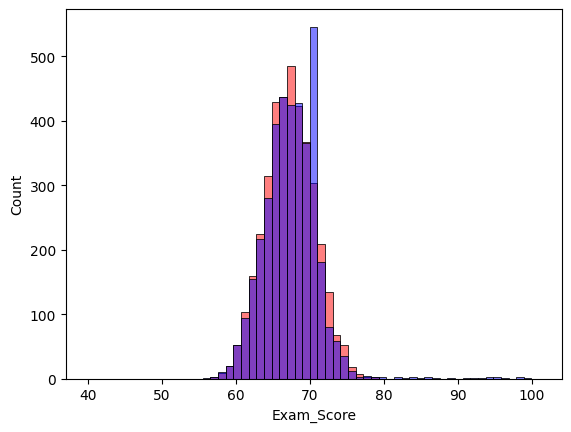

In [43]:
bins = np.linspace(40,101,60)

sns.histplot(y_pred, color="red", alpha=0.5, bins=bins)
sns.histplot(y_train, color="blue", alpha=0.5, bins=bins)
plt.show()

In [44]:
df_val.iloc[20,:].to_dict()

{'Hours_Studied': 21,
 'Attendance': 77,
 'Parental_Involvement': 'Medium',
 'Access_to_Resources': 'Low',
 'Extracurricular_Activities': 1,
 'Sleep_Hours': 5,
 'Previous_Scores': 94,
 'Motivation_Level': 'Low',
 'Internet_Access': 1,
 'Tutoring_Sessions': 1,
 'Family_Income': 'Medium',
 'Teacher_Quality': 'High',
 'Peer_Influence': 'Negative',
 'Physical_Activity': 3,
 'Learning_Disabilities': 0,
 'Parental_Education_Level': 'High School',
 'Distance_from_Home': 'Far',
 'School_Public': 1,
 'Gender_Male': 1}

In [45]:
def test_examples(line):
    dict_example = df_val.iloc[line,:].to_dict()
    X_example = dv.transform(dict_example)
    y_example = linear_regression_model.predict(X_example)

    return y_val[line], y_example

In [46]:
for student in [20, 33, 300, 245]:
    print(test_examples(student))

(np.int64(65), array([64.92944558]))
(np.int64(59), array([59.61977592]))
(np.int64(58), array([58.50863359]))
(np.int64(68), array([67.62172711]))


In [47]:
dict_full_train = df_full_train.to_dict(orient="records")
X_full_train = dv.transform(dict_full_train)

cross_val_score(LinearRegression(), X_full_train, y_full_train, scoring="neg_root_mean_squared_error", cv=10).mean()

np.float64(-1.9421303387766133)

## I try removing certain low correlation columns to check if the model gets better

In [48]:
def custom_columns_regression(columns_removed: list):
    
    col_removal_test = {
        "column_removed":[],
        "rmse":[]
    }
    for col in columns_removed:
        selected_col = df_full_train.columns.to_list()
        selected_col.remove(col)
        df = df_full_train[selected_col].copy()
        dict_custom = df.to_dict(orient="records")
        
        dv_custom = DictVectorizer(sparse=False)
        X_custom_train = dv_custom.fit_transform(dict_custom)

        col_removal_test["column_removed"].append(col)
        col_removal_test["rmse"].append(cross_val_score(LinearRegression(), X_custom_train, y_full_train, scoring="neg_root_mean_squared_error", cv=10).mean())

    return col_removal_test


In [49]:
scores = custom_columns_regression(mi_col_rank_desc[-8:].to_list())

In [50]:
df_scores = pd.DataFrame(scores)

In [51]:
df_scores

,column_removed,rmse
0,Distance_from_Home,-1.970870
1,Motivation_Level,-1.982824
2,Teacher_Quality,-1.967103
3,Learning_Disabilities,-1.958284
4,Extracurricular_Activities,-1.962176
5,Internet_Access,-1.959466
6,Gender_Male,-1.941639
7,School_Public,-1.942042


The only one that improves the rmse is the removal of "School_Public" and "Gender_Male"

In [52]:
selected_col = df_full_train.columns.to_list()
selected_col = [x for x in selected_col if x not in ["Gender_Male","School_Public"]]
df_drop_2_col = df_full_train[selected_col].copy()
dict_custom = df_drop_2_col.to_dict(orient="records")

dv_custom = DictVectorizer(sparse=False)
X_custom_train = dv_custom.fit_transform(dict_custom)

cross_val_score(LinearRegression(), X_custom_train, y_full_train, scoring="neg_root_mean_squared_error", cv=10).mean()


np.float64(-1.9415534700993908)

# Decision trees

In [68]:
dv = DictVectorizer(sparse=False)

dict_train = df_train.to_dict(orient="records")
X_train = dv.fit_transform(dict_train)

dt = DecisionTreeRegressor(random_state=10)

dt.fit(X_train,y_train)

dict_val = df_val.to_dict(orient="records")
X_val = dv.fit_transform(dict_val)
y_pred = dt.predict(X_val)
root_mean_squared_error(y_val, y_pred)

3.5958657905571307

In [69]:
scores_depth = {
    "max_depth":[],
    "rmse":[]
}

for depth in range(1,11):
    dt = DecisionTreeRegressor(max_depth=depth, random_state=10)

    dt.fit(X_train,y_train)

    y_pred = dt.predict(X_val)
    scores_depth["max_depth"].append(depth)
    scores_depth["rmse"].append(root_mean_squared_error(y_val, y_pred))
    

In [70]:
df_scores_depth = pd.DataFrame(scores_depth)

<Axes: xlabel='max_depth'>

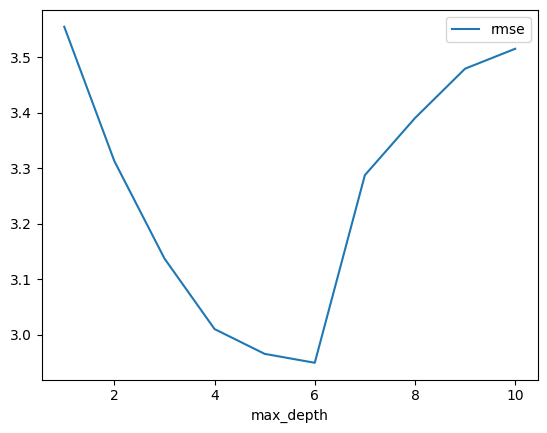

In [71]:
df_scores_depth.plot(y="rmse", x="max_depth")

In [72]:
df_scores_depth

,max_depth,rmse
0,1,3.555226
1,2,3.312864
2,3,3.137157
3,4,3.009863
4,5,2.965147
5,6,2.949051
6,7,3.287558
7,8,3.390486
8,9,3.479625
9,10,3.515548


In [73]:
scores_min_samples_leaf = {
    "max_depth":[],
    "rmse":[],
    "min_samples_leaf":[],
}

for depth in [4, 5, 6, 7, 8]:
    for min_leaf in [1, 5, 10, 15, 20, 500, 100, 200]:
        dt = DecisionTreeRegressor(max_depth=depth, min_samples_leaf=min_leaf, random_state=10)

        dt.fit(X_train,y_train)

        y_pred = dt.predict(X_val)
        scores_min_samples_leaf["max_depth"].append(depth)
        scores_min_samples_leaf["min_samples_leaf"].append(min_leaf)
        scores_min_samples_leaf["rmse"].append(root_mean_squared_error(y_val, y_pred))

In [74]:
df_scores_depth = pd.DataFrame(scores_min_samples_leaf)

In [75]:
df_scores_depth.sort_values(by="rmse").head()

,max_depth,rmse,min_samples_leaf
27,7,2.906208,15
34,8,2.906273,10
35,8,2.910574,15
28,7,2.912271,20
36,8,2.917587,20


The results, as expected, are not as good as with Linear Regression

## Next we are testing random forests

In [76]:
rt = RandomForestRegressor()

In [77]:
scores = {
    "max_depth":[],
    "rmse":[],
    "min_samples_leaf":[],
}

for depth in [4, 5, 6, 7, 8]:
    for min_leaf in [1, 5, 10, 15, 20, 500, 100, 200]:
        rt = RandomForestRegressor(max_depth=depth, min_samples_leaf=min_leaf, random_state=10)

        rt.fit(X_train,y_train)

        y_pred = rt.predict(X_val)
        scores["max_depth"].append(depth)
        scores["min_samples_leaf"].append(min_leaf)
        scores["rmse"].append(root_mean_squared_error(y_val, y_pred))

df_scores = pd.DataFrame(scores)

df_scores.sort_values(by="rmse").head()

,max_depth,rmse,min_samples_leaf
34,8,2.681423,10
33,8,2.683698,5
35,8,2.705064,15
26,7,2.714539,10
32,8,2.714577,1


Score improved quite a bit with Random Forests.

Now I will test different n_estimators amount using max_depth = 8 

In [78]:
scores = {
    "rmse":[],
    "min_samples_leaf":[],
    "n_estimators":[],
}

for s in [7,8,9]:
    for n in range(10,201,10):
        rt = RandomForestRegressor(n_estimators=n, max_depth=8, min_samples_leaf=s)

        rt.fit(X_train,y_train)

        y_pred = rt.predict(X_val)
        scores["n_estimators"].append(n)
        scores["min_samples_leaf"].append(s)
        scores["rmse"].append(root_mean_squared_error(y_val, y_pred))

df_scores = pd.DataFrame(scores)

df_scores.sort_values(by="rmse").head()

,rmse,min_samples_leaf,n_estimators
2,2.665042,7,30
59,2.667993,9,200
15,2.668361,7,160
25,2.668551,8,60
53,2.669262,9,140


root mean squared error is reduced by a small %.

## Final model selected: Linear Regression

In [ ]:
features = ['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home']

dv = DictVectorizer(sparse=False)

dict_full_train = df_full_train[features].to_dict(orient="records")
X_full_train = dv.fit_transform(dict_full_train)

linear_regression_model = LinearRegression()
linear_regression_model.fit(X_full_train, y_full_train)

dict_test = df_test[features].to_dict(orient="records")
X_test = dv.transform(dict_test)

y_pred = linear_regression_model.predict(X_test)

root_mean_squared_error(y_test, y_pred)

2.32942643593056